# 1. Zonal plots of clouds, circulation and moisture in the Atlantic ITCZ

In this notebook, we will look at generating zonal mean profiles of cloud condensate, humidity and vertical and meriodional motion in the tropical Atlantic. This domain was inspired by the ORCESTRA field campaign, and is designed to provide insight into the coupling between convection and circulations in the tropics across multiple scales

---

WARNING: This notebook requires the [python-stratify](https://github.com/SciTools/python-stratify) library, which is not included in the hackathon environment by default. Please run `conda install conda-forge::python-stratify` to install this library before running the notebook.

In [1]:
import intake
from datetime import datetime
from functools import partial

import numpy as np
import pandas as pd
import xarray as xr
import uxarray

import healpix
import easygems.healpix as egh
import easygems.remap as egr
import stratify

import matplotlib.pyplot as plt

Use zoom 6, at approximately 1 degree. We could go higher than this but this is sufficient resolution for quick insights

In [2]:
zoom = 6
grid_spacing = 64 / 2**zoom
dxy = 1.11e5 * grid_spacing

Load 3D data from ICON 2.5km atmosphere only simulation (note 3D data is instantaneous only)

In [3]:
catalogue = intake.open_catalog("https://digital-earths-global-hackathon.github.io/catalog/catalog.yaml")

In [4]:
dataset = catalogue.online.icon_d3hp003(zoom=zoom, time="PT6H", time_method="inst", chunks={}).to_dask()

/home/users/wkjones/miniforge3/envs/hackathon_env/lib/python3.12/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),


In [5]:
dataset

<xarray.Dataset> Size: 85GB
Dimensions:       (crs: 1, time: 1700, cell: 49152, pressure: 30,
                   pressure_rva: 3)
Coordinates:
  * crs           (crs) float32 4B nan
  * pressure      (pressure) int64 240B 5 10 20 50 ... 92500 95000 97500 100000
  * pressure_rva  (pressure_rva) int64 24B 16 18 23
  * time          (time) datetime64[ns] 14kB 2020-01-01T06:00:00 ... 2021-03-01
Dimensions without coordinates: cell
Data variables: (12/23)
    egpvi         (time, cell) float32 334MB dask.array<chunksize=(24, 49152), meta=np.ndarray>
    einvi         (time, cell) float32 334MB dask.array<chunksize=(24, 49152), meta=np.ndarray>
    ekhvi         (time, cell) float32 334MB dask.array<chunksize=(24, 49152), meta=np.ndarray>
    ekvvi         (time, cell) float32 334MB dask.array<chunksize=(24, 49152), meta=np.ndarray>
    hur           (time, pressure, cell) float32 10GB dask.array<chunksize=(8, 2, 49152), meta=np.ndarray>
    hus           (time, pressure, cell) float32 10GB dask.array<chunksize=(8, 2, 49152), meta=np.ndarray>
    ...            ...
    ua            (time, pressure, cell) float32 10GB dask.array<chunksize=(8, 2, 49152), meta=np.ndarray>
    uas           (time, cell) float32 334MB dask.array<chunksize=(24, 49152), meta=np.ndarray>
    va            (time, pressure, cell) float32 10GB dask.array<chunksize=(8, 2, 49152), meta=np.ndarray>
    vas           (time, cell) float32 334MB dask.array<chunksize=(24, 49152), meta=np.ndarray>
    wa            (time, pressure, cell) float32 10GB dask.array<chunksize=(8, 2, 49152), meta=np.ndarray>
    zg            (time, pressure, cell) float32 10GB dask.array<chunksize=(8, 2, 49152), meta=np.ndarray>

Define a lat/lon domain for regridding, covering the tropical Atlantic

In [6]:
lon = xr.DataArray(
    np.arange(285 + grid_spacing/2, 360, grid_spacing),
    dims=("lon",), 
    name="lon", 
    attrs=dict(units="degrees", standard_name="longitude")
)
lat = xr.DataArray(
    np.arange(30 - grid_spacing/2, -30, -grid_spacing), 
    dims=("lat",), 
    name="lat", 
    attrs=dict(units="degrees", standard_name="latitude")
)

pix = xr.DataArray(
    healpix.ang2pix(dataset.crs.healpix_nside, *np.meshgrid(lon, lat), nest=dataset.crs.healpix_order, lonlat=True),
    coords=(lat, lon),
)

Test regridding a variable and taking zonal mean:

In [7]:
dataset.va.sel(cell=pix).mean("lon")

<xarray.DataArray 'va' (time: 1700, pressure: 30, lat: 60)> Size: 12MB
dask.array<mean_agg-aggregate, shape=(1700, 30, 60), dtype=float32, chunksize=(8, 2, 60), chunktype=numpy.ndarray>
Coordinates:
  * pressure  (pressure) int64 240B 5 10 20 50 100 ... 92500 95000 97500 100000
  * time      (time) datetime64[ns] 14kB 2020-01-01T06:00:00 ... 2021-03-01
  * lat       (lat) float64 480B 29.5 28.5 27.5 26.5 ... -26.5 -27.5 -28.5 -29.5

Issues with some chunks failing to load on the fly (and resulting in NaNs) have been experienced. As the dataset isn't too big, let's load all of the variables we want to avoid this issue.

We'll also select the final 12 months of the model run to avoid the spin-up period:

In [8]:
dataset = dataset.sel(time=slice(datetime(2020,3,1), datetime(2021,3,1)))[
    ["hur", "qall", "ta", "va", "wa", "zg"]
].load()

In [9]:
dataset

<xarray.Dataset> Size: 52GB
Dimensions:   (time: 1461, pressure: 30, cell: 49152)
Coordinates:
  * pressure  (pressure) int64 240B 5 10 20 50 100 ... 92500 95000 97500 100000
  * time      (time) datetime64[ns] 12kB 2020-03-01 ... 2021-03-01
Dimensions without coordinates: cell
Data variables:
    hur       (time, pressure, cell) float32 9GB 0.001606 0.001687 ... 88.03
    qall      (time, pressure, cell) float32 9GB 0.0 0.0 ... 6.979e-06 2.41e-05
    ta        (time, pressure, cell) float32 9GB 215.6 215.1 ... 298.8 298.8
    va        (time, pressure, cell) float32 9GB 5.587 13.97 ... -1.344 -3.672
    wa        (time, pressure, cell) float32 9GB 0.1572 0.2006 ... 0.001145
    zg        (time, pressure, cell) float32 9GB 6.905e+04 6.907e+04 ... 100.9

## Plotting

For the zonal plots, we want three components: streamlines showing the w and v wind components, a filled contour showing condensate, and contour lines to show relative humidity. Let's test plotting these individually on the whole dataset:

### Streamlines

The `matplotlib` `streamplot` function requires that both the x and y axis have constant grid spacing, and need to be in the corresponding units to the velocities (i.e. in m for m/s). To handle this, we will regrid the fields to a fixed vertical spaced grid using the `stratify` library. For consistency, we will also do this for the condensate and moisture for the contour plots. For more accurate results, we should perform the zonal regridding before taking the time and longitudinal mean, but for performance reasons we will do it afterwards. Over the ocean, the grid spacing shouldn't vary too much so results should be similar

In [10]:
# First calculate the zonal average height of the dataset
zonal_zg = dataset.zg.sel(cell=pix).mean(["time","lon"])

# Then use this to regrid the zonal mean w and v fields to a fixed height spacing:
heights = np.linspace(0,2e4,40)

# Note that we want ascending values, but zg is descending, so we flip the variables along the pressure axis
zonal_w = stratify.interpolate(
    heights, zonal_zg.values[::-1], dataset.wa.sel(cell=pix).mean(["time","lon"]).values[::-1], 
    axis=0, extrapolation="linear"
)
zonal_v = stratify.interpolate(
    heights, zonal_zg.values[::-1], dataset.va.sel(cell=pix).mean(["time","lon"]).values[::-1], 
    axis=0, extrapolation="linear"
)

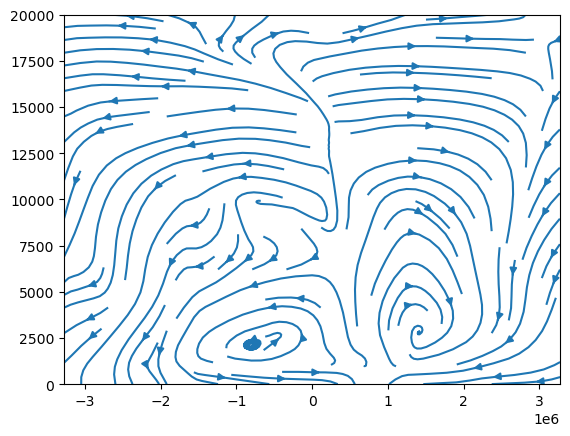

In [11]:
# Test streamplot: note that we multiply lat by the grid spacing in meters
plt.streamplot(
    zonal_zg.lat[::-1].values * dxy, heights, zonal_v[:, ::-1], zonal_w[:, ::-1], 
)

### Condensate contours

For condensate we will use filled contours across a key range of values. We also need to take the zonal mean and regrid this data:

In [12]:
zonal_qall = stratify.interpolate(
    heights, zonal_zg.values[::-1], dataset.qall.sel(cell=pix).mean(["time","lon"]).values[::-1], 
    axis=0, extrapolation="linear"
)

<>:5: SyntaxWarning: invalid escape sequence '\m'
<>:5: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2180330/1895406632.py:5: SyntaxWarning: invalid escape sequence '\m'
  plt.colorbar(cntr_qall, orientation="vertical", label="Cloud condensate [$\mathrm{kg \cdot m^{-3}}$]")


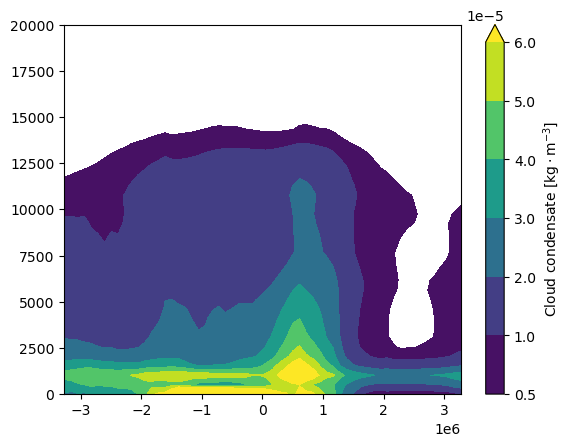

In [13]:
cntr_qall = plt.contourf(
    zonal_zg.lat[::-1].values * dxy, heights, zonal_qall[:, ::-1], 
    [5e-6, 1e-5, 2e-5, 3e-5, 4e-5, 5e-5, 6e-5], extend="max"
)
plt.colorbar(cntr_qall, orientation="vertical", label="Cloud condensate [$\mathrm{kg \cdot m^{-3}}$]")

### Relative humidity

Finally, we will plot relative humidity using contour lines:

In [14]:
zonal_hur = stratify.interpolate(
    heights, zonal_zg.values[::-1], dataset.hur.sel(cell=pix).mean(["time","lon"]).values[::-1], 
    axis=0, extrapolation="linear"
)

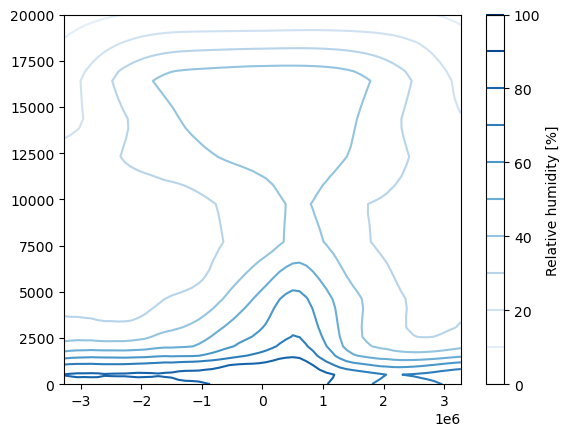

In [15]:
cntr_hur = plt.contour(
    zonal_zg.lat[::-1].values * dxy, heights, zonal_hur[:, ::-1], 
    np.linspace(0,100,11), cmap="Blues"
)
plt.colorbar(cntr_hur, orientation="vertical", label="Relative humidity [%]")

### Combining them all

Let's test combining all three elements, along with a dashed line to show the tropopause temperature inversion

<>:18: SyntaxWarning: invalid escape sequence '\m'
<>:18: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2180330/4122821276.py:18: SyntaxWarning: invalid escape sequence '\m'
  plt.colorbar(cntr_qall, orientation="vertical", label="Cloud condensate [$\mathrm{kg \cdot m^{-3}}$]")


Text(0.5, 1.0, 'ICON Atlantic ITCZ Zonal mean')

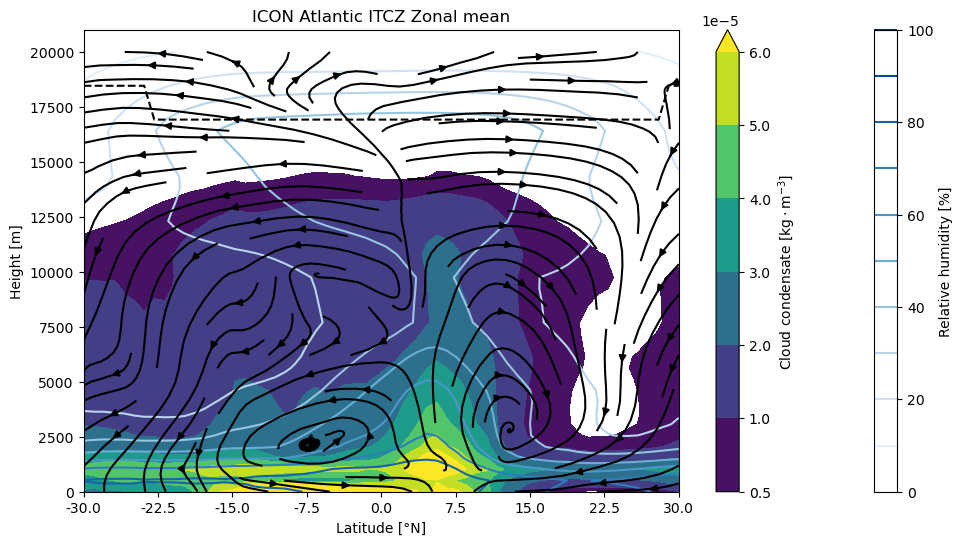

In [16]:
plt.figure(figsize=(12,6))

zonal_ta = stratify.interpolate(
    heights, zonal_zg.values[::-1], dataset.ta.sel(cell=pix).mean(["time","lon"]).values[::-1], 
    axis=0, extrapolation="linear"
)

cntr_hur = plt.contour(
    zonal_zg.lat[::-1].values * dxy, heights, zonal_hur[:, ::-1], 
    np.linspace(0,100,11), cmap="Blues"
)
plt.colorbar(cntr_hur, orientation="vertical", label="Relative humidity [%]")

cntr_qall = plt.contourf(
    zonal_zg.lat[::-1].values * dxy, heights, zonal_qall[:, ::-1], 
    [5e-6, 1e-5, 2e-5, 3e-5, 4e-5, 5e-5, 6e-5], extend="max"
)
plt.colorbar(cntr_qall, orientation="vertical", label="Cloud condensate [$\mathrm{kg \cdot m^{-3}}$]")

plt.streamplot(
    zonal_zg.lat[::-1].values * dxy, heights, zonal_v[:, ::-1], zonal_w[:, ::-1], 
    color="black"
)

plt.plot(zonal_zg.lat[::-1].values * dxy, heights[zonal_ta.argmin(0)], "k--")

plt.xticks(np.linspace(-29.5,29.5,9) * dxy, np.linspace(-30,30,9))
plt.ylabel("Height [m]")
plt.xlabel("Latitude [°N]")
plt.title(f'ICON Atlantic ITCZ Zonal mean')

## Monthly plots

Now, using `groupby`, we can iterate over each month of the simulation and produce zonal plots for each to see the month-to-month evolution of the ITCZ:

<>:42: SyntaxWarning: invalid escape sequence '\m'
<>:42: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2180330/1181739928.py:42: SyntaxWarning: invalid escape sequence '\m'
  plt.colorbar(cntr_qall, ax=ax, orientation="vertical", label="Cloud condensate [$\mathrm{kg \cdot m^{-3}}$]")


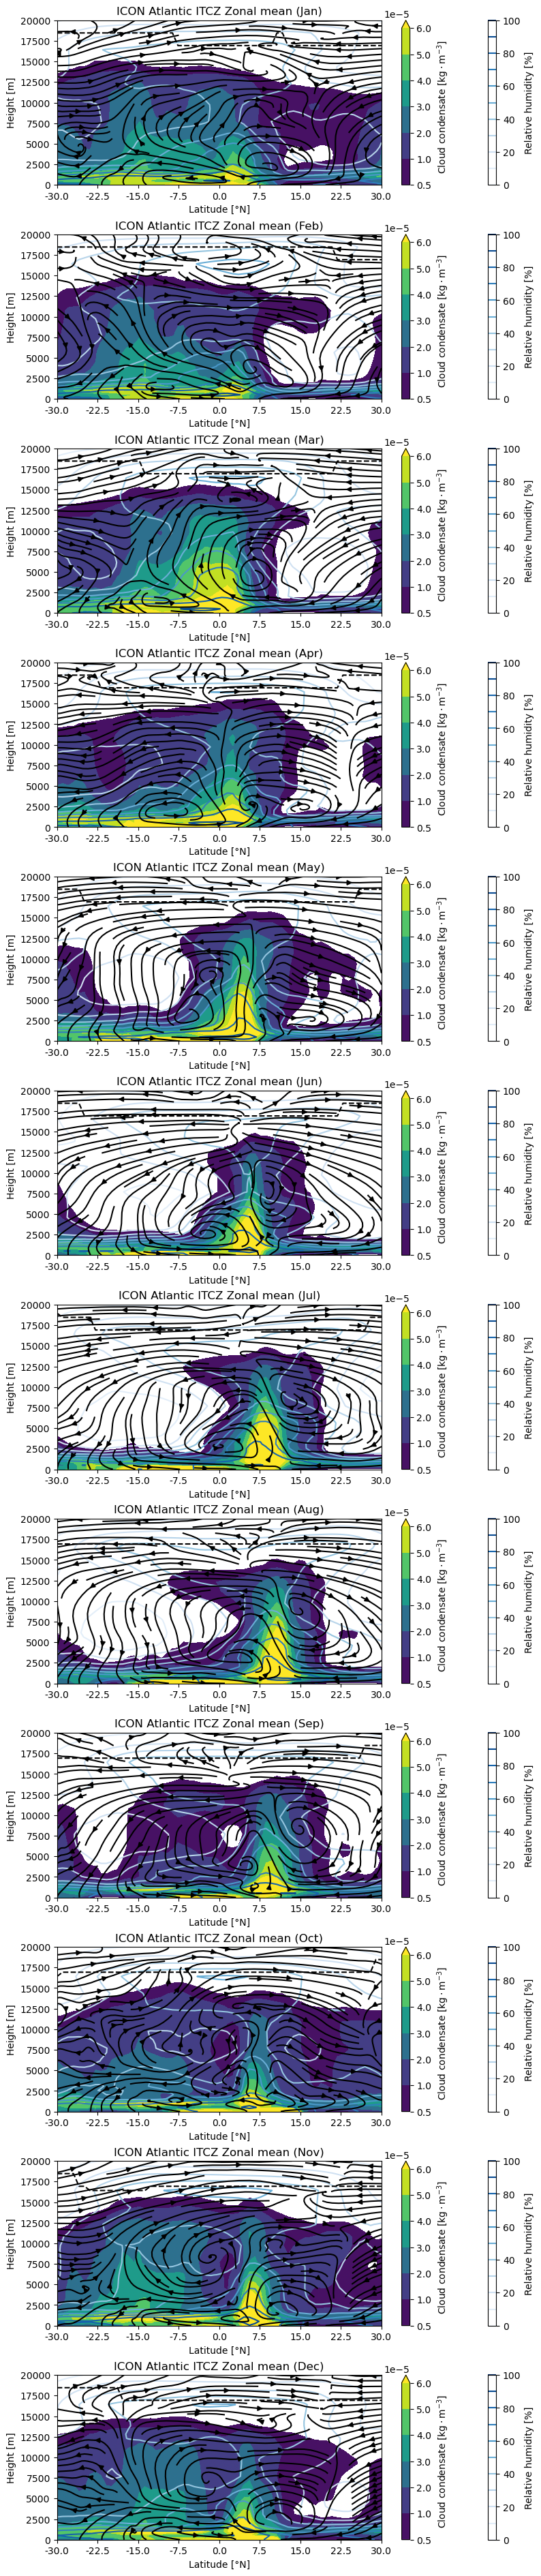

In [17]:
fig, axes = plt.subplots(12, 1, figsize=(9.6,48))

heights = np.linspace(0,2e4,40)

for ax, month, (_, ds) in zip(
    axes, 
    ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"],
    dataset.sel(time=slice(datetime(2020,3,1), datetime(2021,3,1))).groupby("time.month")
):
    zonal_zg = ds.zg.sel(cell=pix).mean(["time","lon"])
    zonal_w = stratify.interpolate(
        heights, zonal_zg.values[::-1], ds.wa.sel(cell=pix).mean(["time","lon"]).values[::-1], 
        axis=0, extrapolation="linear"
    )
    zonal_v = stratify.interpolate(
        heights, zonal_zg.values[::-1], ds.va.sel(cell=pix).mean(["time","lon"]).values[::-1], 
        axis=0, extrapolation="linear"
    )
    zonal_qall = stratify.interpolate(
        heights, zonal_zg.values[::-1], ds.qall.sel(cell=pix).mean(["time","lon"]).values[::-1], 
        axis=0, extrapolation="linear"
    )
    zonal_ta = stratify.interpolate(
        heights, zonal_zg.values[::-1], ds.ta.sel(cell=pix).mean(["time","lon"]).values[::-1], 
        axis=0, extrapolation="linear"
    )
    zonal_hur = stratify.interpolate(
        heights, zonal_zg.values[::-1], ds.hur.sel(cell=pix).mean(["time","lon"]).values[::-1], 
        axis=0, extrapolation="linear"
    )
    
    cntr_hur = ax.contour(
        zonal_zg.lat[::-1].values * dxy, heights, zonal_hur[:, ::-1], 
        np.linspace(0,100,11), cmap="Blues"
    )
    plt.colorbar(cntr_hur, ax=ax, orientation="vertical", label="Relative humidity [%]")
    
    cntr_qall = ax.contourf(
        zonal_zg.lat[::-1].values * dxy, heights, zonal_qall[:, ::-1], 
        [5e-6, 1e-5, 2e-5, 3e-5, 4e-5, 5e-5, 6e-5], extend="max"
    )
    plt.colorbar(cntr_qall, ax=ax, orientation="vertical", label="Cloud condensate [$\mathrm{kg \cdot m^{-3}}$]")
    
    ax.streamplot(
        zonal_zg.lat[::-1].values * dxy, heights, zonal_v[:, ::-1], zonal_w[:, ::-1], 
        color="black"
    )
    
    ax.plot(zonal_zg.lat[::-1].values * dxy, heights[zonal_ta.argmin(0)], "k--")
    
    ax.set_xticks(np.linspace(-30+grid_spacing/2,30-grid_spacing/2,9) * dxy, np.linspace(-30,30,9))
    ax.set_ylim([heights[0], heights[-1]])
    ax.set_ylabel("Height [m]")
    ax.set_xlabel("Latitude [°N]")
    ax.set_title(f'ICON Atlantic ITCZ Zonal mean ({month})')


plt.subplots_adjust(hspace=0.3)